In [ ]:
'''
From Subfolder 1, we found that having different MIC chromosome level have little effect on having sex every generation but do
have a great impact on having sex every 100 generations.

Here by adopting having random mating every 100 generations, we compared the fitness dynamics of having 100 loci per MIC 
chromosome (since 100 loci in total, thus only have 1 MIC chromosome) but different # of crossover events under population size 
N = 20 during 10K generations.

We simulated having 0, 1, 5,10, 15 and 20 crossovers in the single MIC chromosomes. Also we compared the results of having 0 
crossover event in our crossover model with the one that didn't include crossover event (the one in Subfolder 1), to make sure
the results are consistent.
'''


In [1]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
%matplotlib inline

In [2]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 20})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')

In [3]:
generation_list = []

for i in range(10002):
    generation_list.append(i)
    
print(len(generation_list))

10002


In [4]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180813_Multiple loci in Germ Chromosome_Original Model\Data\Have Crossover\1.2. RM E100_100 loci Per Chromosome_Different CrossOver")

In [5]:
cr_file = ['Fitness_WF_RM_20_E100_GermL_1PerCh_FirstFragThenAmp.csv', 'Fitness_WF_RM_20_E100_GermL_100PerCh_FirstFragThenAmp.csv', \
          'Fitness_WF_RM_20_E100_GermL_100PerCh_CrossOver_1.csv',\
          'Fitness_WF_RM_20_E100_GermL_100PerCh_CrossOver_5.csv', 'Fitness_WF_RM_20_E100_GermL_100PerCh_CrossOver_10.csv', \
          'Fitness_WF_RM_20_E100_GermL_100PerCh_CrossOver_15.csv', 'Fitness_WF_RM_20_E100_GermL_100PerCh_CrossOver_20.csv']

In [6]:
cr_fit_mean = []
cr_fit_std = []

for i in cr_file:
    f = pd.read_csv(i,dtype=str)
    
    fit_mean = []
    fit_std = []
       
    fit_mean.extend(list(pd.Series(f.meanFit,dtype=float)))
    fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
        
    cr_fit_mean.append(fit_mean)
    cr_fit_std.append(fit_std)

Fitness comparison between different fragmentation level

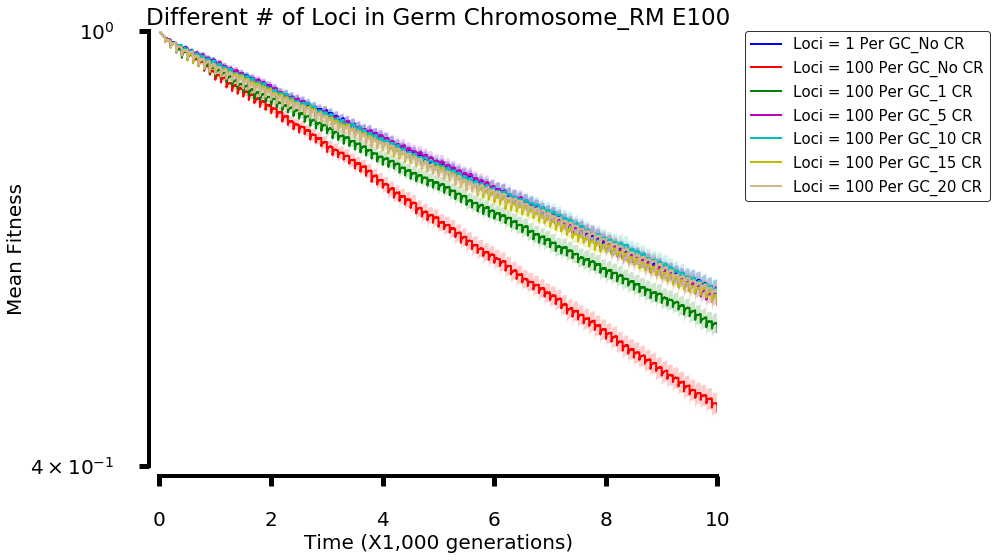

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(0,10000)


t = generation_list

a = cr_fit_mean[0]  # No CR_1 locus
error_a = list(1.96* np.array(cr_fit_std[0])/((500)**0.5))

b = cr_fit_mean[1]  # No CR_100 loci
error_b = list(1.96* np.array(cr_fit_std[1])/((500)**0.5))


c = cr_fit_mean[2]  # 100 loci_1 CR
error_c = list(1.96* np.array(cr_fit_std[2])/((500)**0.5))

d = cr_fit_mean[3]  # 100 loci_5 CR
error_d = list(1.96* np.array(cr_fit_std[3])/((500)**0.5))


e = cr_fit_mean[4]  # 100 loci_10 CR
error_e = list(1.96* np.array(cr_fit_std[4])/((500)**0.5))

f = cr_fit_mean[5]  # 100 loci_15 CR
error_f = list(1.96* np.array(cr_fit_std[5])/((500)**0.5))

g = cr_fit_mean[6]  # 100 loci_20 CR
error_g = list(1.96* np.array(cr_fit_std[6])/((500)**0.5))




ax.set_title('Different # of Loci in Germ Chromosome_RM E100', fontsize =23)
ax.set_xlabel('Time (X1,000 generations)', fontsize =20)
ax.set_ylabel('Mean Fitness', fontsize =20)

ax.set_yscale('log')

ax.plot(t,a,'b', label = 'Loci = 1 Per GC_No CR',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.2, facecolor='b')

ax.plot(t,b,'r', label = 'Loci = 100 Per GC_No CR', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.2, facecolor='r')


ax.plot(t,c,'g', label = 'Loci = 100 Per GC_1 CR', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.2, facecolor='g')

ax.plot(t,d,'m', label = 'Loci = 100 Per GC_5 CR', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(d)- np.array(error_d), np.array(d)+ np.array(error_d), alpha =0.2, facecolor='m')

ax.plot(t,e,'c', label = 'Loci = 100 Per GC_10 CR', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(e)- np.array(error_e), np.array(e)+ np.array(error_e), alpha =0.2, facecolor='c')

ax.plot(t,f,'y', label = 'Loci = 100 Per GC_15 CR', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(f)- np.array(error_f), np.array(f)+ np.array(error_f), alpha =0.2, facecolor='y')


ax.plot(t,g,'tan', label = 'Loci = 100 Per GC_20 CR', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(g)- np.array(error_g), np.array(g)+ np.array(error_g), alpha =0.2, facecolor='tan')

ax.minorticks_off()


legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =15)
frame = legend.get_frame()
frame.set_edgecolor('black')

extraticks=[0.4]
ax.set_yticks(list(ax.get_yticks()) + extraticks)
ax.set_ylim(4*10**(-1), 1)


plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

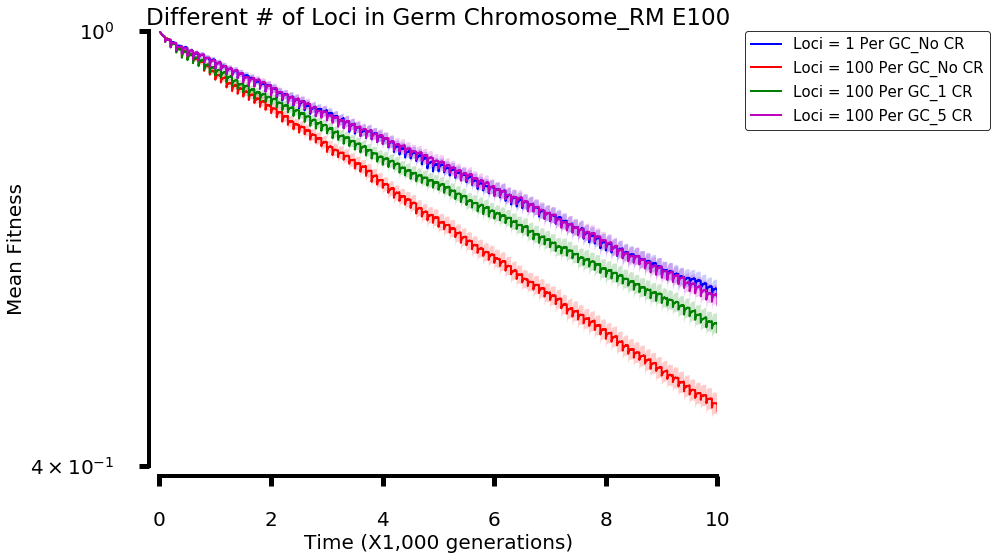

In [7]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(0,10000)


t = generation_list

a = cr_fit_mean[0]  # No CR_1 locus
error_a = list(1.96* np.array(cr_fit_std[0])/((500)**0.5))

b = cr_fit_mean[1]  # No CR_100 loci
error_b = list(1.96* np.array(cr_fit_std[1])/((500)**0.5))


c = cr_fit_mean[2]  # 100 loci_1 CR
error_c = list(1.96* np.array(cr_fit_std[2])/((500)**0.5))

d = cr_fit_mean[3]  # 100 loci_5 CR
error_d = list(1.96* np.array(cr_fit_std[3])/((500)**0.5))


e = cr_fit_mean[4]  # 100 loci_10 CR
error_e = list(1.96* np.array(cr_fit_std[4])/((500)**0.5))

f = cr_fit_mean[5]  # 100 loci_15 CR
error_f = list(1.96* np.array(cr_fit_std[5])/((500)**0.5))

g = cr_fit_mean[6]  # 100 loci_20 CR
error_g = list(1.96* np.array(cr_fit_std[6])/((500)**0.5))




ax.set_title('Different # of Loci in Germ Chromosome_RM E100', fontsize =23)
ax.set_xlabel('Time (X1,000 generations)', fontsize =20)
ax.set_ylabel('Mean Fitness', fontsize =20)

ax.set_yscale('log')

ax.plot(t,a,'b', label = 'Loci = 1 Per GC_No CR',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.2, facecolor='b')

ax.plot(t,b,'r', label = 'Loci = 100 Per GC_No CR', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.2, facecolor='r')


ax.plot(t,c,'g', label = 'Loci = 100 Per GC_1 CR', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.2, facecolor='g')

ax.plot(t,d,'m', label = 'Loci = 100 Per GC_5 CR', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(d)- np.array(error_d), np.array(d)+ np.array(error_d), alpha =0.2, facecolor='m')

# ax.plot(t,e,'c', label = 'Loci = 100 Per GC_10 CR', linewidth=2.0, alpha =1)
# ax.fill_between(t, np.array(e)- np.array(error_e), np.array(e)+ np.array(error_e), alpha =0.2, facecolor='c')

# ax.plot(t,f,'y', label = 'Loci = 100 Per GC_15 CR', linewidth=2.0, alpha =1)
# ax.fill_between(t, np.array(f)- np.array(error_f), np.array(f)+ np.array(error_f), alpha =0.2, facecolor='y')


# ax.plot(t,g,'tan', label = 'Loci = 100 Per GC_20 CR', linewidth=2.0, alpha =1)
# ax.fill_between(t, np.array(g)- np.array(error_g), np.array(g)+ np.array(error_g), alpha =0.2, facecolor='tan')

ax.minorticks_off()


legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =15)
frame = legend.get_frame()
frame.set_edgecolor('black')

extraticks=[0.4]
ax.set_yticks(list(ax.get_yticks()) + extraticks)
ax.set_ylim(4*10**(-1), 1)


plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

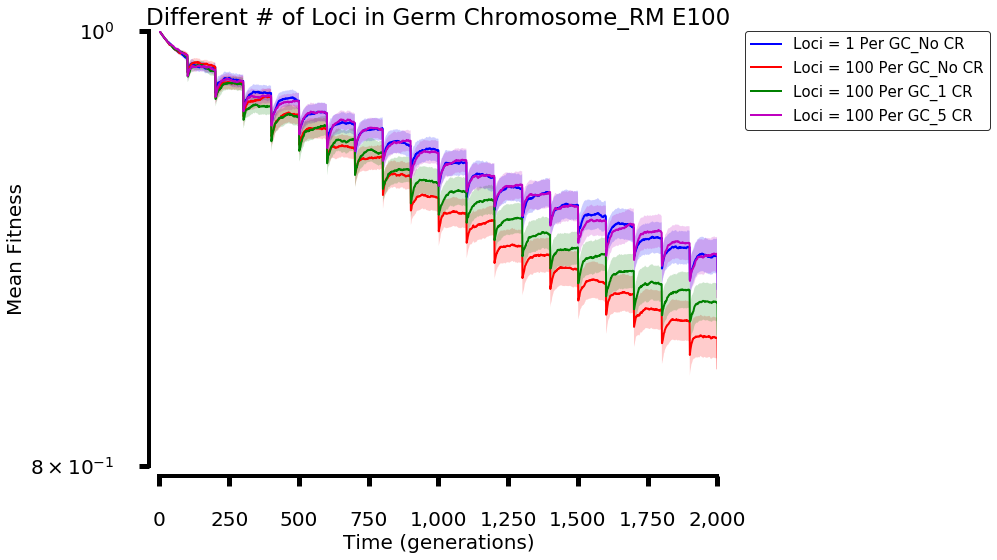

In [13]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(0,2000)


t = generation_list

a = cr_fit_mean[0]  # No CR_1 locus
error_a = list(1.96* np.array(cr_fit_std[0])/((500)**0.5))

b = cr_fit_mean[1]  # No CR_100 loci
error_b = list(1.96* np.array(cr_fit_std[1])/((500)**0.5))


c = cr_fit_mean[2]  # 100 loci_1 CR
error_c = list(1.96* np.array(cr_fit_std[2])/((500)**0.5))

d = cr_fit_mean[3]  # 100 loci_5 CR
error_d = list(1.96* np.array(cr_fit_std[3])/((500)**0.5))


e = cr_fit_mean[4]  # 100 loci_10 CR
error_e = list(1.96* np.array(cr_fit_std[4])/((500)**0.5))

f = cr_fit_mean[5]  # 100 loci_15 CR
error_f = list(1.96* np.array(cr_fit_std[5])/((500)**0.5))

g = cr_fit_mean[6]  # 100 loci_20 CR
error_g = list(1.96* np.array(cr_fit_std[6])/((500)**0.5))




ax.set_title('Different # of Loci in Germ Chromosome_RM E100', fontsize =23)
ax.set_xlabel('Time (generations)', fontsize =20)
ax.set_ylabel('Mean Fitness', fontsize =20)

ax.set_yscale('log')

ax.plot(t,a,'b', label = 'Loci = 1 Per GC_No CR',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.2, facecolor='b')

ax.plot(t,b,'r', label = 'Loci = 100 Per GC_No CR', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.2, facecolor='r')


ax.plot(t,c,'g', label = 'Loci = 100 Per GC_1 CR', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.2, facecolor='g')

ax.plot(t,d,'m', label = 'Loci = 100 Per GC_5 CR', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(d)- np.array(error_d), np.array(d)+ np.array(error_d), alpha =0.2, facecolor='m')

# ax.plot(t,e,'c', label = 'Loci = 100 Per GC_10 CR', linewidth=2.0, alpha =1)
# ax.fill_between(t, np.array(e)- np.array(error_e), np.array(e)+ np.array(error_e), alpha =0.2, facecolor='c')

# ax.plot(t,f,'y', label = 'Loci = 100 Per GC_15 CR', linewidth=2.0, alpha =1)
# ax.fill_between(t, np.array(f)- np.array(error_f), np.array(f)+ np.array(error_f), alpha =0.2, facecolor='y')


# ax.plot(t,g,'tan', label = 'Loci = 100 Per GC_20 CR', linewidth=2.0, alpha =1)
# ax.fill_between(t, np.array(g)- np.array(error_g), np.array(g)+ np.array(error_g), alpha =0.2, facecolor='tan')

ax.minorticks_off()


legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =15)
frame = legend.get_frame()
frame.set_edgecolor('black')

extraticks=[0.8]
ax.set_yticks(list(ax.get_yticks()) + extraticks)
ax.set_ylim(8*10**(-1), 1)


plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

Control_Comparison of 0 crossover with not include crossover

In [17]:
control_file = ['Fitness_WF_RM_20_E100_GermL_100PerCh_FirstFragThenAmp.csv', 'Fitness_WF_RM_20_E100_GermL_100PerCh_CrossOver_0.csv']

In [18]:
control_fit_mean = []
control_fit_std = []

for i in control_file:
    f = pd.read_csv(i,dtype=str)
    
    fit_mean = []
    fit_std = []
       
    fit_mean.extend(list(pd.Series(f.meanFit,dtype=float)))
    fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
        
    control_fit_mean.append(fit_mean)
    control_fit_std.append(fit_std)

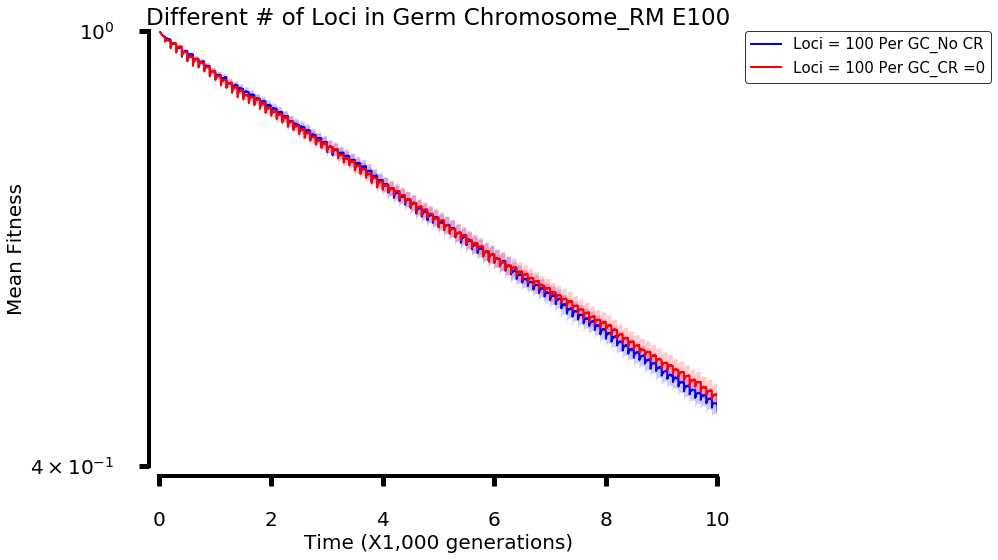

In [21]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(0,10000)


t = generation_list

a = control_fit_mean[0]  # No CR_1 locus
error_a = list(1.96* np.array(control_fit_std[0])/((500)**0.5))

b = control_fit_mean[1]  # No CR_100 loci
error_b = list(1.96* np.array(control_fit_std[1])/((500)**0.5))




ax.set_title('Different # of Loci in Germ Chromosome_RM E100', fontsize =23)
ax.set_xlabel('Time (X1,000 generations)', fontsize =20)
ax.set_ylabel('Mean Fitness', fontsize =20)

ax.set_yscale('log')

ax.plot(t,a,'b', label = 'Loci = 100 Per GC_No CR',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.2, facecolor='b')

ax.plot(t,b,'r', label = 'Loci = 100 Per GC_CR =0', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.2, facecolor='r')




ax.minorticks_off()


legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =15)
frame = legend.get_frame()
frame.set_edgecolor('black')

extraticks=[0.4]
ax.set_yticks(list(ax.get_yticks()) + extraticks)
ax.set_ylim(4*10**(-1), 1)


plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))